In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("sentiment_dataset.csv")

In [3]:
df.head()

,id,text,label,sentiment
0,0,"Cooking microwave pizzas, yummy",2,positive
1,1,Any plans of allowing sub tasks to show up in ...,1,neutral
2,2,"I love the humor, I just reworded it. Like sa...",2,positive
3,3,naw idk what ur talkin about,1,neutral
4,4,That sucks to hear. I hate days like that,0,negative


In [ ]:
df = df.drop(columns=["id", "sentiment"], axis=1, inplace=True)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31232 entries, 0 to 31231
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    31232 non-null  str  
 1   label   31232 non-null  int64
dtypes: int64(1), str(1)
memory usage: 488.1 KB


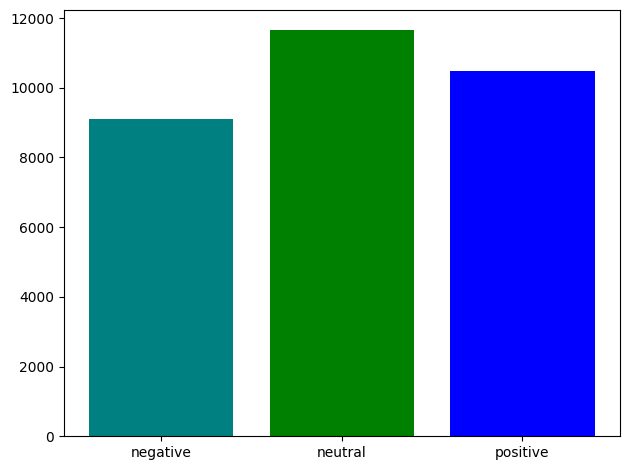

In [ ]:
import matplotlib.pyplot as plt

counts = df['label'].value_counts().sort_index()
label_names = ['negative', 'neutral', 'positive']

plt.bar(label_names, counts.values, color=['teal', 'green', 'blue'])
plt.tight_layout()
plt.show()

In [9]:
from string import punctuation
import emoji

list = [punctuation, emoji.EMOJI_DATA.keys()]

def cleantext(text):
    text = str(text)
    return ''.join([x for x in text if x not in list])

In [10]:
df["text"] = df["text"].apply(cleantext)

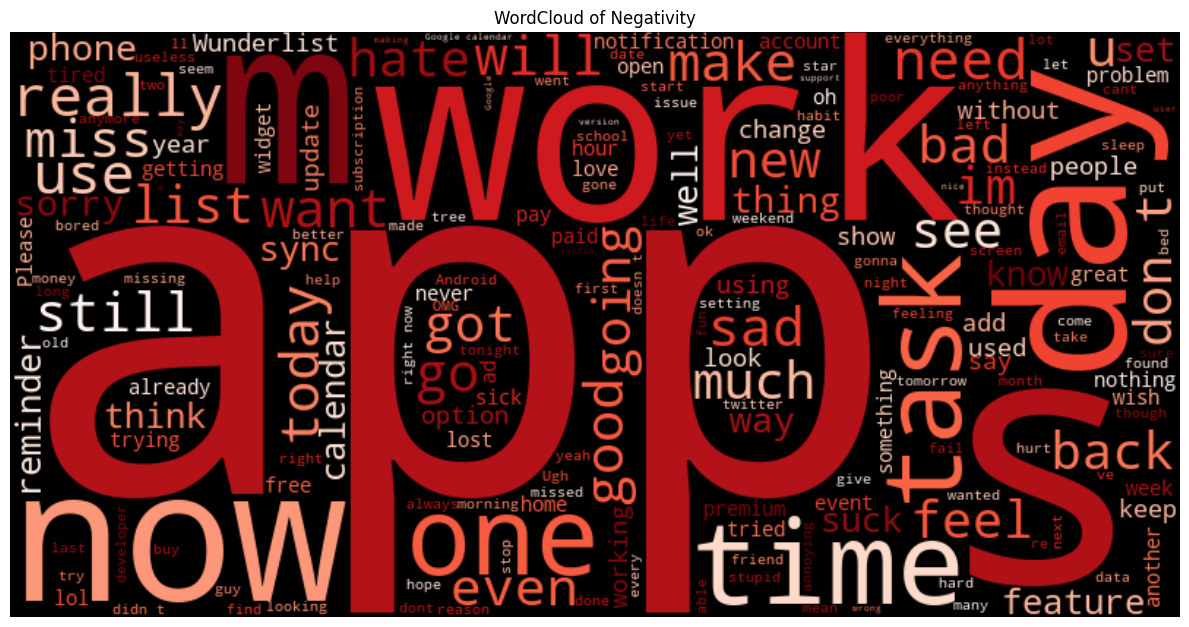

In [12]:
from wordcloud import WordCloud

negative = ' '.join(df[df['label'] == 0]['text'])
negativecloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative)

plt.figure(figsize=(12, 8))
plt.imshow(negativecloud, interpolation='bilinear')

plt.axis('off')
plt.title('WordCloud of Negativity')
plt.tight_layout()
plt.show()

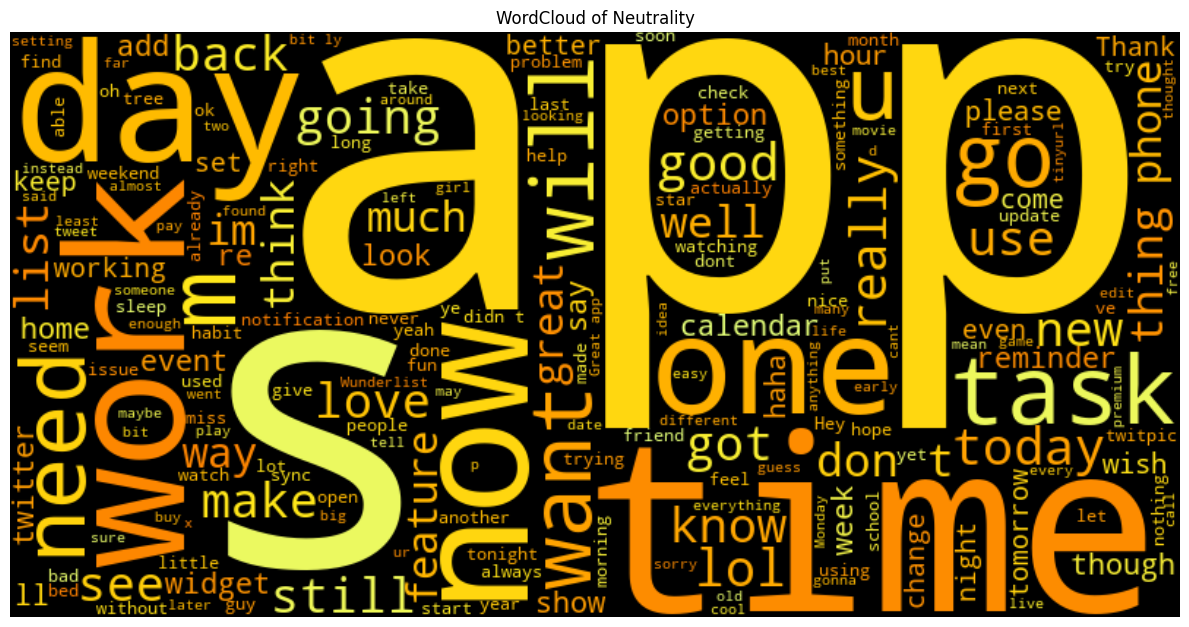

In [15]:
neutral = ' '.join(df[df['label'] == 1]['text'])
neutralcloud = WordCloud(width=800, height=400, background_color='black', colormap='Wistia').generate(neutral)

plt.figure(figsize=(12, 8))
plt.imshow(neutralcloud, interpolation='bilinear')

plt.axis('off')
plt.title('WordCloud of Neutrality')
plt.tight_layout()
plt.show()

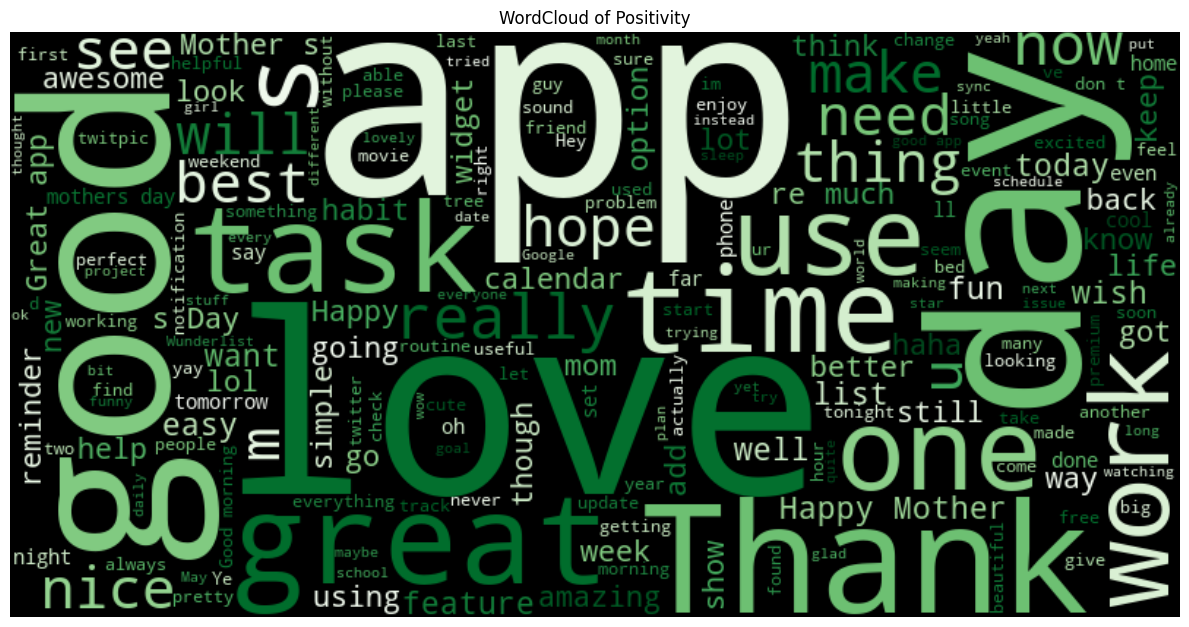

In [19]:
positive = ' '.join(df[df['label'] == 2]['text'])
positivecloud = WordCloud(width=800, height=400, background_color='black', colormap='Greens').generate(positive)

plt.figure(figsize=(12, 8))
plt.imshow(positivecloud, interpolation='bilinear')

plt.axis('off')
plt.title('WordCloud of Positivity')
plt.tight_layout()
plt.show()

In [22]:
import numpy as np

X = np.array(df["text"])
y = np.array(df["label"])

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline

themodel = Pipeline([
    ("countvectorizer", CountVectorizer()),
    ("tfidftransformer", TfidfTransformer()),
    ("Xgboost", XGBClassifier())
])

In [25]:
model = themodel.fit(X, y)

In [26]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.64      0.73      1824
           1       0.66      0.87      0.75      2322
           2       0.86      0.76      0.81      2101

    accuracy                           0.76      6247
   macro avg       0.79      0.75      0.76      6247
weighted avg       0.79      0.76      0.76      6247



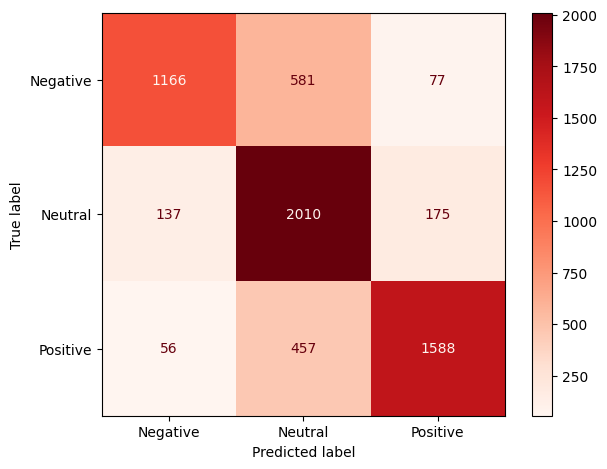

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Reds', display_labels=['Negative', 'Neutral', 'Positive'])
plt.tight_layout()
plt.show()

In [30]:
import joblib as jb

jb.dump(model, "sentiment_model.pkl")

['sentiment_model.pkl']